# 01 — Data Loading & Exploratory Analysis
**RetailMind · Data Science Practicum 2 · Sai Teja Sunku**

End-to-end EDA on the two bundled datasets — Rossmann (store-day aggregates)
and Walmart (transactional). Every chart shown here uses the **same canonical
EDA helpers**, which is what makes the rest of the pipeline universal.

| Concept | Module |
|---|---|
| File ingestion (CSV / XLSX / Parquet) | `retailmind.ingest` |
| Data profiler (quality + density) | `retailmind.profiler` |
| Canonical EDA (overview, seasonality, promo lift) | `retailmind.eda` |


In [1]:
# Common setup
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Load both datasets

In [2]:
from retailmind.ingest import load_file, load_dataset

ros_raw = load_dataset('../train.csv', auxiliary_paths=['../store.csv'])
wal_raw = load_file('../walmart Retail Data.xlsx')

print(f'Rossmann raw shape : {ros_raw.shape}')
print(f'Walmart  raw shape : {wal_raw.shape}')
print()
print('Rossmann columns:', list(ros_raw.columns))
print()
print('Walmart  columns:', list(wal_raw.columns))

Rossmann raw shape : (1017209, 18)
Walmart  raw shape : (8399, 25)

Rossmann columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Walmart  columns: ['City', 'Customer Age', 'Customer Name', 'Customer Segment', 'Discount', 'Number of Records', 'Order Date', 'Order ID', 'Order Priority', 'Order Quantity', 'Product Base Margin', 'Product Category', 'Product Container', 'Product Name', 'Product Sub-Category', 'Profit', 'Region', 'Row ID', 'Sales', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State', 'Unit Price', 'Zip Code']


## 2. Quality profile (before any modelling)

In [3]:
from retailmind.profiler import profile

for label, df in [('Rossmann', ros_raw), ('Walmart', wal_raw)]:
    p = profile(df)
    print(f'--- {label} ---')
    print(f'  Quality score      : {p.quality_score}/100')
    print(f'  Suggested freq     : {p.suggested_freq}')
    print(f'  % missing          : {p.pct_missing:.2f}%')
    print(f'  Duplicate rows     : {p.duplicate_rows:,}')
    print(f'  Has explicit sales : {p.has_explicit_sales}')
    print(f'  Has quantity       : {p.has_quantity}')
    print(f'  Has unit price     : {p.has_unit_price}')
    print(f'  Candidate sales    : {p.candidate_sales_cols[:5]}')
    print(f'  Candidate entities : {p.candidate_entity_cols[:5]}')
    print()

--- Rossmann ---
  Quality score      : 88/100
  Suggested freq     : D
  % missing          : 12.04%
  Duplicate rows     : 0
  Has explicit sales : True
  Has quantity       : False
  Has unit price     : False
  Candidate sales    : ['Store', 'DayOfWeek', 'Sales', 'Customers', 'CompetitionDistance']
  Candidate entities : ['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'StoreType']

--- Walmart ---
  Quality score      : 100/100
  Suggested freq     : D
  % missing          : 0.46%
  Duplicate rows     : 0
  Has explicit sales : True
  Has quantity       : True
  Has unit price     : True
  Candidate sales    : ['Customer Age', 'Discount', 'Order Quantity', 'Product Base Margin', 'Sales']
  Candidate entities : ['Customer Segment', 'Order Priority', 'Order Quantity', 'Product Category', 'Product Container']



## 3. Canonicalise both datasets so EDA helpers work uniformly

In [4]:
from retailmind.mapper import SchemaMapper
from retailmind.canonical import canonicalize
from retailmind import eda

# Rossmann
ros_schema = SchemaMapper().infer(ros_raw).schema
ros_canon = canonicalize(ros_raw, ros_schema, freq='D')

# Walmart
wal_schema = SchemaMapper().infer(wal_raw).schema
wal_canon = canonicalize(wal_raw, wal_schema, freq='D')

print(f'Rossmann canonical : {ros_canon.shape}  ·  {ros_canon["entity_id"].nunique()} entities')
print(f'Walmart  canonical : {wal_canon.shape}  ·  {wal_canon["entity_id"].nunique()} entities')
ros_canon.head(3)

Rossmann canonical : (1050329, 18)  ·  1115 entities
Walmart  canonical : (1460, 26)  ·  1 entities


,date,entity_id,sales,customers,holiday,promo,is_open,SchoolHoliday,StoreType,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Assortment,CompetitionDistance
0,2013-01-01,1,0.0,0.0,0.0,0.0,0.0,1.0,c,9.0,2008.0,0.0,NaN,NaN,None,2.0,a,1270.0
1,2013-01-02,1,5530.0,668.0,0.0,0.0,1.0,1.0,c,9.0,2008.0,0.0,NaN,NaN,None,3.0,a,1270.0
2,2013-01-03,1,4327.0,578.0,0.0,0.0,1.0,1.0,c,9.0,2008.0,0.0,NaN,NaN,None,4.0,a,1270.0


## 4. Overview KPIs

In [5]:
ros_overview = eda.overview(ros_canon)
wal_overview = eda.overview(wal_canon)

print('=== ROSSMANN ===')
print(json.dumps(ros_overview, indent=2))
print()
print('=== WALMART ===')
print(json.dumps(wal_overview, indent=2))

=== ROSSMANN ===
{
  "rows": 1050329,
  "entities": 1115,
  "date_min": "2013-01-01",
  "date_max": "2015-07-31",
  "span_days": 942,
  "total_sales": 5873180623.0,
  "mean_daily_sales": 5591.7532725460305,
  "median_daily_sales": 5628.0,
  "pct_nonzero_sales_days": 0.8038795463135836,
  "sales_p95": 12046.0,
  "sales_max": 41551.0
}

=== WALMART ===
{
  "rows": 1460,
  "entities": 1,
  "date_min": "2012-01-01",
  "date_max": "2015-12-30",
  "span_days": 1460,
  "total_sales": 14915600.824000001,
  "mean_daily_sales": 10216.164947945206,
  "median_daily_sales": 7129.47325,
  "pct_nonzero_sales_days": 0.9712328767123287,
  "sales_p95": 30980.72629999999,
  "sales_max": 117076.414
}


## 5. Total sales over time — both datasets

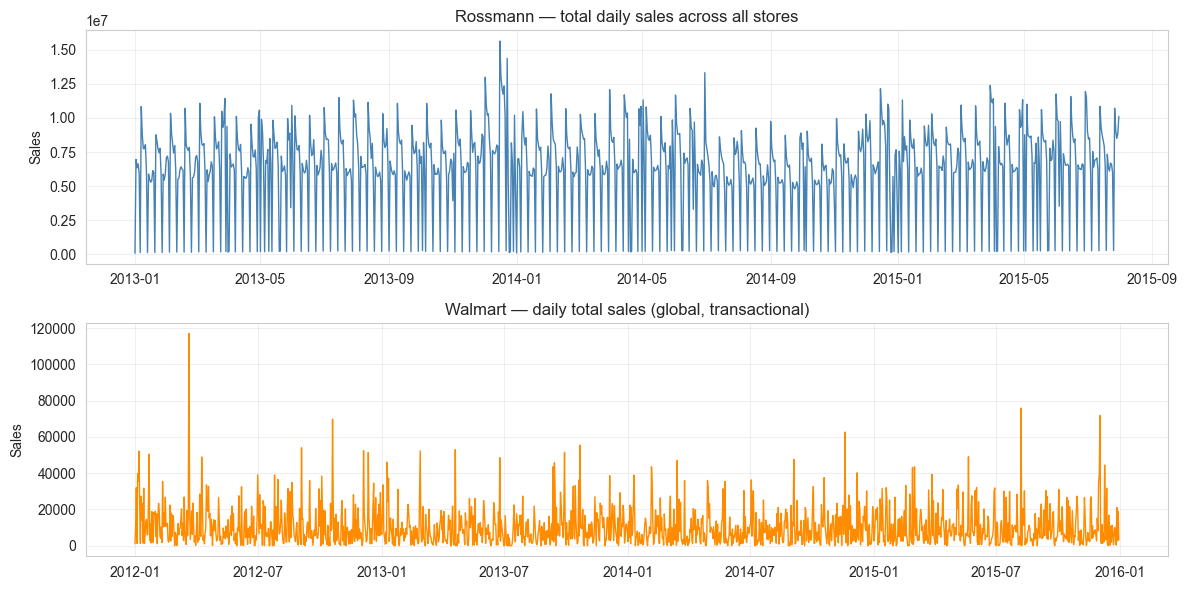

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

ros_total = ros_canon.groupby('date')['sales'].sum()
axes[0].plot(ros_total.index, ros_total.values, color='steelblue', linewidth=1)
axes[0].set_title('Rossmann — total daily sales across all stores')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

wal_total = wal_canon.groupby('date')['sales'].sum()
axes[1].plot(wal_total.index, wal_total.values, color='darkorange', linewidth=1)
axes[1].set_title('Walmart — daily total sales (global, transactional)')
axes[1].set_ylabel('Sales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Day-of-week seasonality — side by side

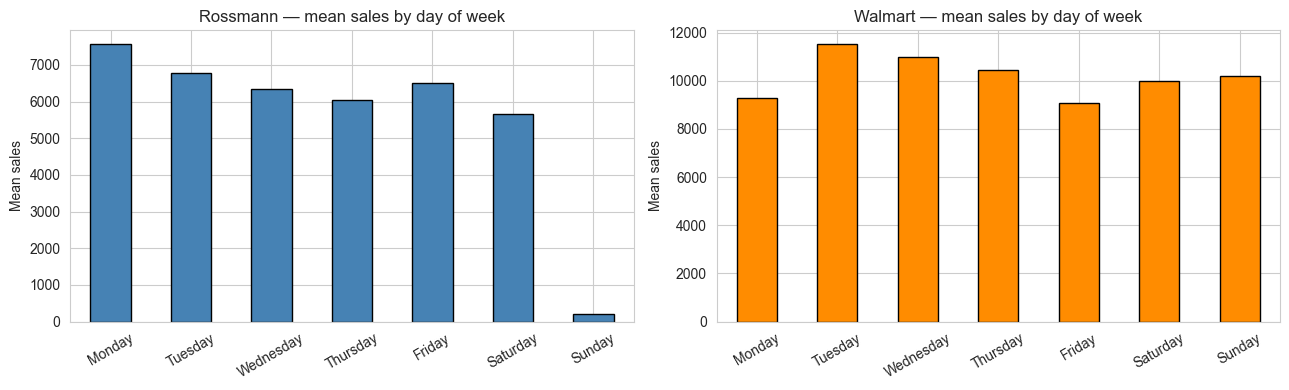

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

ros_dow = pd.Series(eda.seasonality(ros_canon)['dow_mean_sales']).reindex(order)
ros_dow.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Rossmann — mean sales by day of week')
axes[0].set_ylabel('Mean sales')
axes[0].tick_params(axis='x', rotation=30)

wal_dow = pd.Series(eda.seasonality(wal_canon)['dow_mean_sales']).reindex(order)
wal_dow.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Walmart — mean sales by day of week')
axes[1].set_ylabel('Mean sales')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

## 7. Monthly seasonality — both datasets

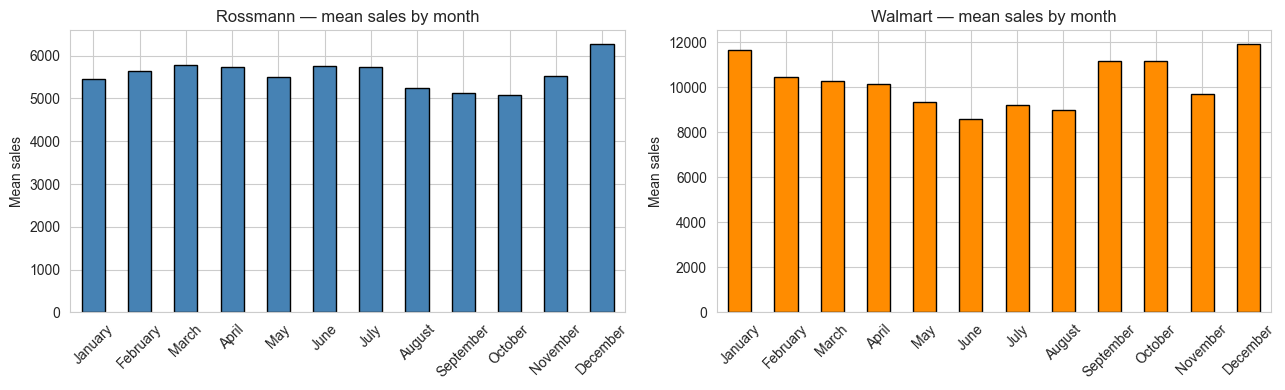

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
month_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

ros_month = pd.Series(eda.seasonality(ros_canon)['month_mean_sales']).reindex(month_order)
ros_month.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Rossmann — mean sales by month')
axes[0].set_ylabel('Mean sales')
axes[0].tick_params(axis='x', rotation=45)

wal_month = pd.Series(eda.seasonality(wal_canon)['month_mean_sales']).reindex(month_order)
wal_month.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Walmart — mean sales by month')
axes[1].set_ylabel('Mean sales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

## 8. Sales distribution (log scale to handle skew)

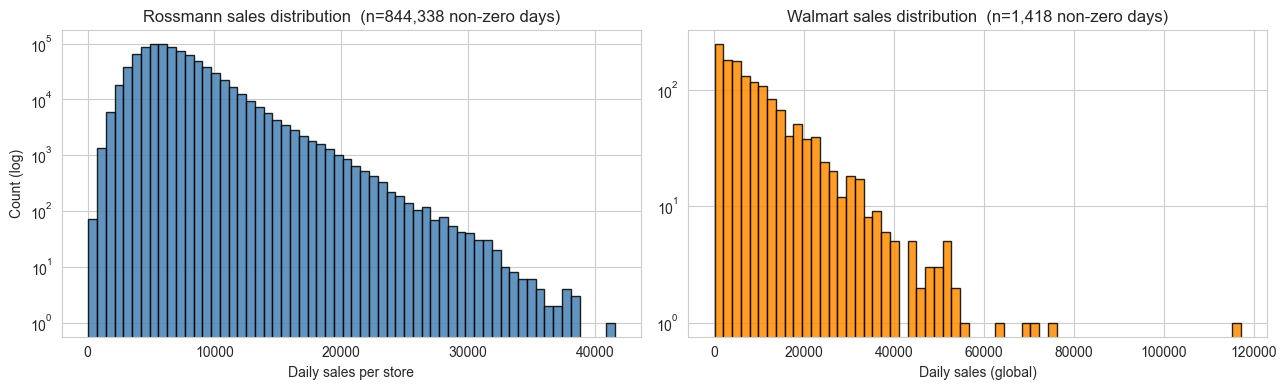

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ros_nz = ros_canon[ros_canon['sales'] > 0]['sales']
axes[0].hist(ros_nz, bins=60, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title(f'Rossmann sales distribution  (n={len(ros_nz):,} non-zero days)')
axes[0].set_xlabel('Daily sales per store')
axes[0].set_ylabel('Count (log)')

wal_nz = wal_canon[wal_canon['sales'] > 0]['sales']
axes[1].hist(wal_nz, bins=60, color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title(f'Walmart sales distribution  (n={len(wal_nz):,} non-zero days)')
axes[1].set_xlabel('Daily sales (global)')

plt.tight_layout(); plt.show()

## 9. Top 15 entities by total sales (Rossmann)
Walmart only has 1 global entity, so this chart is Rossmann-only.

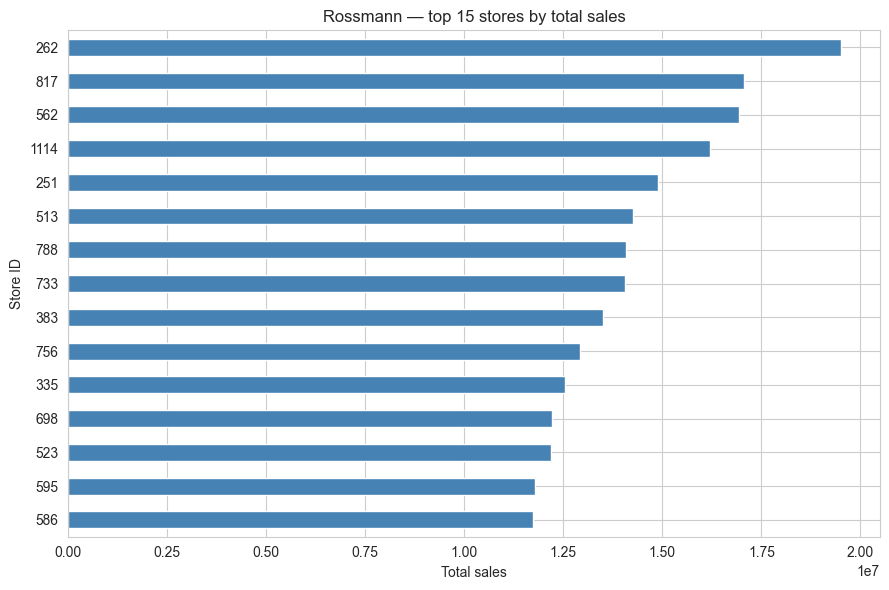

In [10]:
top15 = eda.entity_stats(ros_canon, top=15).reset_index()
top15.plot(kind='barh', x='entity_id', y='total_sales', figsize=(9, 6),
            color='steelblue', legend=False)
plt.gca().invert_yaxis()
plt.title('Rossmann — top 15 stores by total sales')
plt.xlabel('Total sales'); plt.ylabel('Store ID')
plt.tight_layout(); plt.show()

## 10. Yearly trend

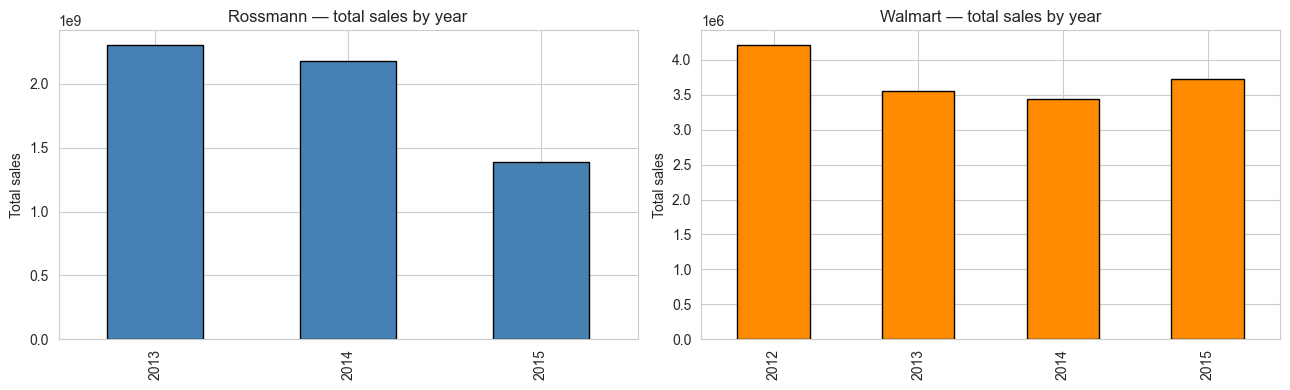

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ros_year = pd.Series(eda.seasonality(ros_canon)['yearly_total'])
ros_year.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Rossmann — total sales by year')
axes[0].set_ylabel('Total sales')

wal_year = pd.Series(eda.seasonality(wal_canon)['yearly_total'])
wal_year.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Walmart — total sales by year')
axes[1].set_ylabel('Total sales')

plt.tight_layout(); plt.show()

## 11. Promotion impact (Rossmann only — Walmart has no promo column)

{
  "promo_days": 421200,
  "nonpromo_days": 629129,
  "mean_sales_on_promo": 7362.787953466287,
  "mean_sales_off_promo": 4406.050805160786,
  "naive_lift_pct": 67.10628812637134
}


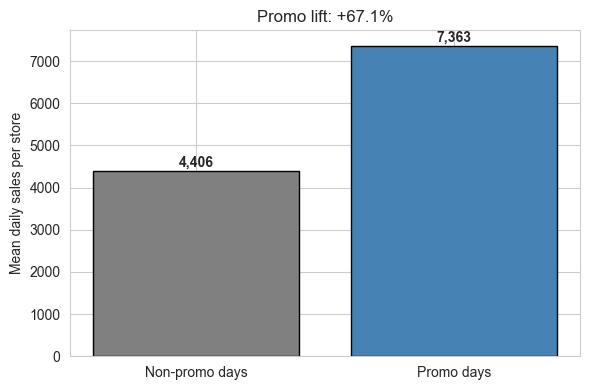

In [12]:
pl = eda.promo_lift(ros_canon)
print(json.dumps(pl, indent=2))

if pl:
    promo_mean = pl['mean_sales_on_promo']
    nopromo_mean = pl['mean_sales_off_promo']
    plt.figure(figsize=(6, 4))
    plt.bar(['Non-promo days', 'Promo days'], [nopromo_mean, promo_mean],
             color=['gray', 'steelblue'], edgecolor='black')
    plt.title(f"Promo lift: +{pl['naive_lift_pct']:.1f}%")
    plt.ylabel('Mean daily sales per store')
    for i, v in enumerate([nopromo_mean, promo_mean]):
        plt.text(i, v + 100, f'{v:,.0f}', ha='center', fontweight='bold')
    plt.tight_layout(); plt.show()

## 12. Missingness map (per dataset)

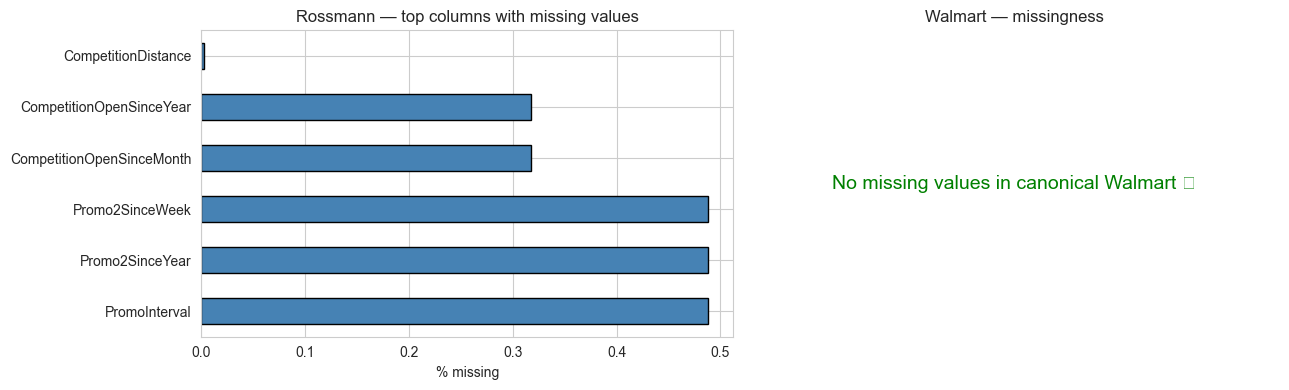

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ros_miss = ros_canon.isna().mean().sort_values(ascending=False)
ros_miss = ros_miss[ros_miss > 0].head(10)
if not ros_miss.empty:
    ros_miss.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Rossmann — top columns with missing values')
    axes[0].set_xlabel('% missing')
else:
    axes[0].text(0.5, 0.5, 'No missing values in canonical Rossmann ✓',
                 ha='center', va='center', fontsize=14, color='green')
    axes[0].set_title('Rossmann — missingness')
    axes[0].axis('off')

wal_miss = wal_canon.isna().mean().sort_values(ascending=False)
wal_miss = wal_miss[wal_miss > 0].head(10)
if not wal_miss.empty:
    wal_miss.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
    axes[1].set_title('Walmart — top columns with missing values')
    axes[1].set_xlabel('% missing')
else:
    axes[1].text(0.5, 0.5, 'No missing values in canonical Walmart ✓',
                 ha='center', va='center', fontsize=14, color='green')
    axes[1].set_title('Walmart — missingness')
    axes[1].axis('off')

plt.tight_layout(); plt.show()

## 13. One-shot EDA report (full JSON)

In [14]:
full_ros = eda.full_report(ros_canon)
print('Rossmann report keys:', list(full_ros.keys()))
print()
print('Overview:')
print(json.dumps(full_ros['overview'], indent=2))

Rossmann report keys: ['overview', 'missing', 'top_entities', 'seasonality', 'promo_lift']

Overview:
{
  "rows": 1050329,
  "entities": 1115,
  "date_min": "2013-01-01",
  "date_max": "2015-07-31",
  "span_days": 942,
  "total_sales": 5873180623.0,
  "mean_daily_sales": 5591.7532725460305,
  "median_daily_sales": 5628.0,
  "pct_nonzero_sales_days": 0.8038795463135836,
  "sales_p95": 12046.0,
  "sales_max": 41551.0
}


## Summary
- `retailmind.ingest` handles file I/O across CSV / Excel / Parquet with auto-typing
- `retailmind.profiler` scores any dataset *before* modelling — flags quality issues + density
- `retailmind.eda` produces consistent reports regardless of the source schema
- Same code, same chart helpers, two completely different datasets

**Next:** [02 — Schema Mapping](02_schema_mapping.ipynb) — the heart of universality.
